# Classical optimizers

In [12]:
from lib.utils import h_and_uccsd
from qiskit_algorithms.optimizers import L_BFGS_B, COBYLA
from qiskit.primitives import StatevectorEstimator
import numpy as np
from matplotlib import pyplot as plt
import time

In [13]:
molecules = [
    ("H2", lambda d: f"H .0 .0 .0; H .0 .0 {d}"),
    ("LiH", lambda d: f"Li .0 .0 .0; H .0 .0 {d}"),
    ("BeH2", lambda d: f"Be .0 .0 .0; H .0 .0 {d}; H .0 .0 {-d}"),
]
mapper = "JW"
optimizer = L_BFGS_B(tol=1e-5) # maxiter=1000
estimator = StatevectorEstimator()


# for name, geom_fn in molecules:
#     geom = geom_fn(0.735)

In [14]:
distances=[0.1, 0.2, 0.5, 0.735, 1.0, 1.5, 2.0, 3.0, 4.0]
iterations = [[] for _ in range(len(distances))]
runtimes=[]
energies=[]
fci_runtimes=[]
fci_energies=[]

In [15]:
for i in range(len(distances)):
    (qubit_hamiltonian, ansatz) = h_and_uccsd(mapper="JW", molecule_string=molecules[0][1](distances[i]))
    def estimate_energy(parameters):
        job = estimator.run(
            [(ansatz, qubit_hamiltonian, parameters)]
        )
        result = job.result()[0].data.evs
        iterations[i].append(result)
        return result

    initial_point = np.zeros(ansatz.num_parameters)
    start = time.perf_counter()
    result = optimizer.minimize(fun=estimate_energy, x0=initial_point)
    end = time.perf_counter()
    runtimes.append(end - start)
    energies.append(result.fun)

In [16]:
# FCI
from lib.utils import get_fci_h2

for i in range(len(distances)):
    start = time.perf_counter()
    fci_energy = get_fci_h2(distances[i])
    end = time.perf_counter()
    fci_runtimes.append(end - start)
    fci_energies.append(fci_energy)

converged SCF energy = 2.71588739329275
converged SCF energy = 0.164175012061695
converged SCF energy = -1.04299627454009
converged SCF energy = -1.116998996754
converged SCF energy = -1.06610864931794
converged SCF energy = -0.910873554594387
converged SCF energy = -0.783792654277353
converged SCF energy = -0.656048251145591
converged SCF energy = -0.614869974042561


[-2.5818113383326984, -2.4884039198016183, -2.113514216310605, -1.857275030202364, -1.6303275411525624, -1.3509341607512602, -1.213229717635579, -1.110024248159498, -1.0654656645443856]
[np.float64(2.709960770867275), np.float64(0.1574821347983626), np.float64(-1.0551597944706266), np.float64(-1.1373060357534004), np.float64(-1.1011503302326187), np.float64(-0.9981493534714101), np.float64(-0.9486411121761855), np.float64(-0.9336318445584986), np.float64(-0.9331713618436487)]


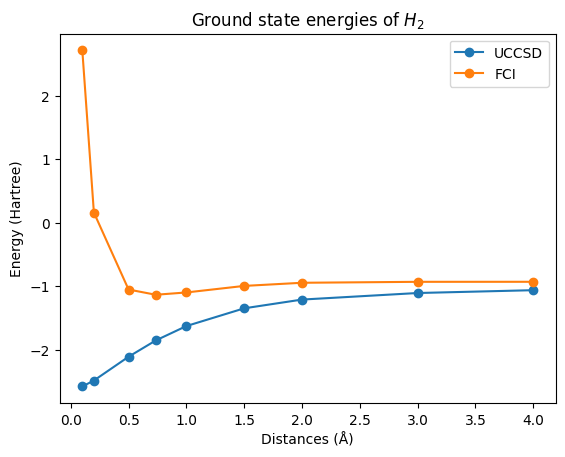

In [17]:
print(energies)
print(fci_energies)
plt.plot(distances, energies, marker='o', linestyle='-', label="UCCSD")
plt.plot(distances, fci_energies, marker='o', linestyle='-', label="FCI")
plt.legend()
plt.xlabel('Distances (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Ground state energies of $H_2$')
plt.show()

In [18]:
optimizer = COBYLA(tol=1e-5) # maxiter=1000

In [19]:
distances=[0.1, 0.2, 0.5, 0.735, 1.0, 1.5, 2.0, 3.0, 4.0]
iterations = [[] for _ in range(len(distances))]
runtimes2=[]
energies2=[]

In [20]:
for i in range(len(distances)):
    (qubit_hamiltonian, ansatz) = h_and_uccsd(mapper="JW", molecule_string=molecules[0][1](distances[i]))
    def estimate_energy(parameters):
        job = estimator.run(
            [(ansatz, qubit_hamiltonian, parameters)]
        )
        result = job.result()[0].data.evs
        iterations[i].append(result)
        return result

    initial_point = np.zeros(ansatz.num_parameters)
    start = time.perf_counter()
    result = optimizer.minimize(fun=estimate_energy, x0=initial_point)
    end = time.perf_counter()
    runtimes2.append(end - start)
    energies2.append(result.fun)

[np.float64(-2.5818113382480354), np.float64(-2.4884039195769905), np.float64(-2.113514216164273), np.float64(-1.8572750300577876), np.float64(-1.630327541081628), np.float64(-1.350934160413321), np.float64(-1.2132297174417277), np.float64(-1.1099461466974094), np.float64(-1.065465616751021)]
[np.float64(2.709960770867275), np.float64(0.1574821347983626), np.float64(-1.0551597944706266), np.float64(-1.1373060357534004), np.float64(-1.1011503302326187), np.float64(-0.9981493534714101), np.float64(-0.9486411121761855), np.float64(-0.9336318445584986), np.float64(-0.9331713618436487)]


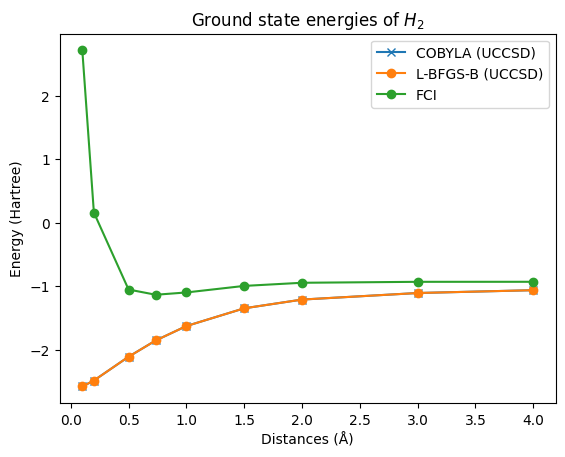

In [22]:
print(energies2)
print(fci_energies)
plt.plot(distances, energies2, marker='x', linestyle='-', label="COBYLA (UCCSD)")
plt.plot(distances, energies, marker='o', linestyle='-', label="L-BFGS-B (UCCSD)")
plt.plot(distances, fci_energies, marker='o', linestyle='-', label="FCI")
plt.legend()
plt.xlabel('Distances (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Ground state energies of $H_2$')
plt.show()